In [5]:
import os, torch
from tqdm import tqdm
from peft import PeftModel
# w
from tqdm import tqdm
def load_curvature_cache(cache_dir):
    cache = {}
    for fname in tqdm(os.listdir(cache_dir)):
        if not fname.endswith(".pt") and 'mlp' in fname.lower():
            continue
        # expected: layer{idx}_{module}.pt, where module uses '_' instead of '.'
        stem = fname[:-3]
        _, rest = stem.split("layer", 1)
        layer_str, mod_str = rest.split("_", 1)
        cache[(int(layer_str), mod_str.replace("_", "."))] = torch.load(os.path.join(cache_dir, fname))
    return cache

curv_cache = load_curvature_cache("/scratch/ps9044/curvature_cache")

def apply_C_decomposition_to_lora_B_drift_measure(
    peft_model: PeftModel,
    alpha: float,
    beta: float,
    thrs_cos: float = 1.0,
    curvature_cache=None,  # {(layer_idx, "self_attn.q_proj"): {"H_cholesky_inv": ..., "nsamples": ...}}
    curvature_device="cpu",
):
    idx = 0
    count = 0
    stats = []
    layerwise_safety_losses = []
    top_100s = []
    top_1000s = []

    for name, param in tqdm(peft_model.items()):
        if "lora" not in name:
            continue

        # parse layer index and target module from PEFT param name:
        # e.g., base_model.model.model.layers.0.self_attn.q_proj.lora_B.weight
        parts = name.split(".")
        layer_idx = int(parts[4])
        target = ".".join(parts[5:7])  # "self_attn.q_proj" or "mlp.down_proj", etc.
        target = target.replace('_', '.')

        if param.shape[0] == 32:
            B = param.to(curvature_device)  # LoRA-A stays untouched here
            continue

        if curvature_cache is not None and (layer_idx, target) in curvature_cache:
            # print(f"Computing metric for layer {layer_idx} target {target}...")
            H_up = curvature_cache[(layer_idx, target)]["H_cholesky_inv"].to(curvature_device)

            safety_loss = torch.matmul(param.data.to(curvature_device), B) ** 2 / (
                torch.diag(H_up).reshape((1, -1))
            ) ** 2

            flat_loss = safety_loss.flatten()
            # sort descending and save list
            top_100_vals, _ = torch.topk(flat_loss, k=100)
            top_1000_vals, _ = torch.topk(flat_loss, k=1000)


            top_100s.append(top_100_vals.sum().item())
            top_1000s.append(top_1000_vals.sum().item())

            layerwise_safety_losses.append(safety_loss.sum().item())

    summary_stats = {
        "layer_idx": layer_idx,
        "target": target,
        "total_loss": safety_loss.sum().item(),
        "mean_loss": safety_loss.mean().item(),
        "max_loss": flat_loss.max().item(),
        "top100_sum": sum(top_100s),
        "top1000_sum": sum(top_1000s),
        "sum_safety_losses": sum(layerwise_safety_losses)
    }

    print(f"Applied C-decomposition with alpha={alpha}, beta={beta}, modified {count} layers.")
    return peft_model, stats, summary_stats

100%|██████████| 224/224 [00:18<00:00, 12.44it/s]


In [15]:
rootfolder = '/scratch/ps9044/newsetting/BeaverTailsSafe5_BeaverTails5_500_fedavg_c10s10_i10_b16a1_l512_r32a64_20260517123537'
# rootfolder = '/scratch/ps9044/newsetting/expguardtrainsafe5_expguardtrain5_500_safelorav2data_c10s10_i10_b16a1_l512_r32a64_20260517123541'
# rootfolder = '/scratch/ps9044/newsetting/PubMedQA7_BeaverTails3_500_safe_lora_c10s10_i10_b16a1_l512_r32a64_20260212170509'
total_rounds = 4
import pickle
round_wise_scores = []
round_wise_2scores = []
for round in range(1,total_rounds):
    checkpoint_path = os.path.join(rootfolder, f"round_{round}.pkl")
    with open(checkpoint_path, "rb") as f:
        data = pickle.load(f)['local_dict_list']
    all_clients_score = []
    all_clients_2score = []
    for client in range(10):
        client_data = data[client]
        
        _, stats, summary_stats = apply_C_decomposition_to_lora_B_drift_measure(
            client_data,
            alpha=0.5,
            beta=0.5,
            thrs_cos=1.0,
            curvature_cache=curv_cache,
            curvature_device="cpu",
        )
        all_clients_score.append(summary_stats['top100_sum'])
        all_clients_2score.append(summary_stats['top1000_sum'])
    print(f"Round {round}")
    # print(all_clients_score)
    round_wise_scores.append(all_clients_score)
    round_wise_2scores.append(all_clients_2score)

100%|██████████| 128/128 [00:21<00:00,  5.82it/s]


Applied C-decomposition with alpha=0.5, beta=0.5, modified 0 layers.


100%|██████████| 128/128 [00:21<00:00,  5.93it/s]


Applied C-decomposition with alpha=0.5, beta=0.5, modified 0 layers.


100%|██████████| 128/128 [00:21<00:00,  5.91it/s]


...

Applied C-decomposition with alpha=0.5, beta=0.5, modified 0 layers.


100%|██████████| 128/128 [00:21<00:00,  5.91it/s]


Applied C-decomposition with alpha=0.5, beta=0.5, modified 0 layers.


100%|██████████| 128/128 [00:21<00:00,  5.91it/s]

Applied C-decomposition with alpha=0.5, beta=0.5, modified 0 layers.
Round 3


[[0.029482659167115344, 0.04876331071500317, 0.02908593041502172, 0.02946928780511371, 0.029755796313111205, 0.02859979878849117, 0.02884661186908488, 0.028819642735470552, 0.02824954608877306, 0.028755970222846372], [0.0843870888784295, 0.09987423034908716, 0.08439616378745995, 0.08530057501775445, 0.08636056464456487, 0.0844025829792372, 0.08352781822759425, 0.08516127174516441, 0.08531662038876675, 0.0840845714265015], [0.1424847450980451, 0.1735257545078639, 0.13922937503957655, 0.14292951884999638, 0.14167941280175, 0.14416679517307784, 0.14481642882310553, 0.14531124787026783, 0.14429073517385405, 0.14275120511592831]]


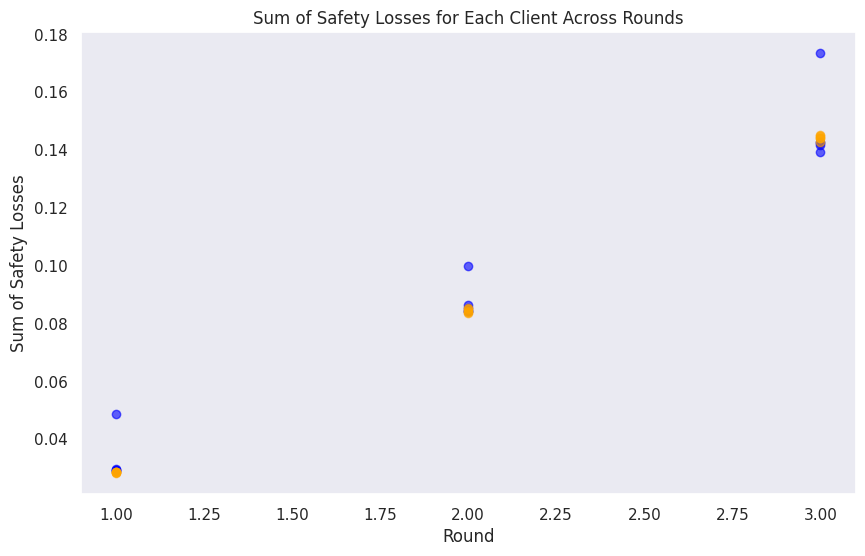

In [16]:
print(round_wise_scores)
import seaborn as sns
sns.set_theme()

benign_clients = [0, 1, 2, 3, 4]

import matplotlib.pyplot as plt
plt.figure(figsize=(10, 6))
for client in range(10):
    client_scores = [round_wise_scores[round][client] for round in range(total_rounds-1)]
    if client in benign_clients:
        plt.scatter(range(1, total_rounds), client_scores, label=f"Client {client}", color='blue', alpha = 0.6)
    else:
        plt.scatter(range(1, total_rounds), client_scores, label=f"Client {client}", color='orange', alpha = 0.6)
plt.xlabel("Round")

plt.ylabel("Sum of Safety Losses")
plt.title("Sum of Safety Losses for Each Client Across Rounds")
# plt.legend()
plt.grid()
plt.show()

In [17]:
safety_dataset[0]

NameError: name 'safety_dataset' is not defined